# task #1 binary, laplace and exponential diff-privacy mechanisms
**based on**: Morris Chang, Di Zhuang, G. Dumindu Samaraweera - *Privacy-Preserving Machine Learning* (2023, Manning)

**dataset**: `brendan45774/test-file` on kaggle.

## dp mechanisms
- **binary**: a literal two-coin-flip `if/else` with a balanced coin (p fixed at 0.5).
- **laplace**: `f(data) + np.random.laplace(0, sensitivity/epsilon)`.
- **exponential**: a python list comprehension for the weights, `np.linalg.norm(.., ord=1)`
  to normalize, and `np.random.choice` to sample.

implementation on titanic dataset:
- **binary**: epsilon-parametrised coin (p derived from epsilon, not hard-coded 0.5),
  drawn in one vectorised pass over the whole column with a single uniform array
  instead of per-person python loops, plus the standard unbiased estimator to recover
  the true count.
- **laplace**: noise generated by **inverse-cdf (inverse transform) sampling** of the
  laplace distribution from a uniform variable - we never call `np.random.laplace`.
  wrapped as a small reusable mechanism object.
- **exponential**: a **numerically stable log-sum-exp softmax** (subtract the max log
  weight) instead of `linalg.norm`, with sampling done by **inverse-cdf on the cumulative
  sum** rather than `np.random.choice`.

each mechanism is applied to a column whose data type fits it:
- binary -> `Survived` (0/1 binary).
- laplace -> numerical values (count of survivors, mean `Fare`).
- exponential -> `Embarked` (categorical).

## import and understand dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("brendan45774/test-file")

print("Path to dataset files:", path)

100%|██████████| 11.2k/11.2k [00:00<00:00, 17.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/brendan45774/test-file/versions/6


In [ ]:
import pandas as pd

In [ ]:
import os
files = os.listdir(path)
print("Files: ", files)

Files:  ['tested.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, files[0]))

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [ ]:
for i in df.columns.tolist():
  print("\nCOLUMN NAME\n", i, "\nDATA TYPE\n", df[i].dtype, "\nUNIQUE VALUES\n", df[i].unique(), "\nVALUE COUNTS\n", df[i].value_counts())
  print("________________________________________________")


COLUMN NAME
 PassengerId 
DATA TYPE
 int64 
UNIQUE VALUES
 [ 892  893  894  895  896  897  898  899  900  901  902  903  904  905
  906  907  908  909  910  911  912  913  914  915  916  917  918  919
  920  921  922  923  924  925  926  927  928  929  930  931  932  933
  934  935  936  937  938  939  940  941  942  943  944  945  946  947
  948  949  950  951  952  953  954  955  956  957  958  959  960  961
  962  963  964  965  966  967  968  969  970  971  972  973  974  975
  976  977  978  979  980  981  982  983  984  985  986  987  988  989
  990  991  992  993  994  995  996  997  998  999 1000 1001 1002 1003
 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014 1015 1016 1017
 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028 1029 1030 1031
 1032 1033 1034 1035 1036 1037 1038 1039 1040 1041 1042 1043 1044 1045
 1046 1047 1048 1049 1050 1051 1052 1053 1054 1055 1056 1057 1058 1059
 1060 1061 1062 1063 1064 1065 1066 1067 1068 1069 1070 1071 1072 1073
 1074 1075 1076 1

## 1. binary mechanism (randomized response) - on `Survived`
book's listing in section 2.2.1. `x` is the true value (0 or 1) and `p` is the
probability of the coin coming up heads. with `p = 0.5` this is the balanced-coin version.

In [ ]:
df['Survived'].value_counts()

,count
Survived,
0,266
1,152


In [ ]:
survived = df["Survived"].dropna().astype(int).values
true_survivors = int(survived.sum())
print("true survivor count:", true_survivors, "/", len(survived))

true survivor count: 152 / 418


In [ ]:
from random import random

In [ ]:
# x indicates the true value, and it can be either 0 or 1
def randomized_response_mechanism(x, p):
    if random() < p: # first coint flip
        return x
    elif random() < p: # second coin flip
        return 1
    else:
        return 0

In [ ]:
import numpy as np

In [ ]:
# higher p = less noise = higher budget.
import math
for p in [0.5, 0.6, 0.7, 0.8, 0.9]:
    reported = [randomized_response_mechanism(x, p) for x in survived]
    reported_ones = int(np.sum(reported))
    budget = math.log(1 + p / ((1 - p) * (1 - p)))   # epsilon formula
    print("p={:.1f} (eps={:.3f}): reported 1s = {:>4} | true = {}".format(
        p, budget, reported_ones, true_survivors))

p=0.5 (eps=1.099): reported 1s =  189 | true = 152
p=0.6 (eps=1.558): reported 1s =  185 | true = 152
p=0.7 (eps=2.172): reported 1s =  191 | true = 152
p=0.8 (eps=3.045): reported 1s =  188 | true = 152
p=0.9 (eps=4.511): reported 1s =  182 | true = 152


## 2. laplace mechanism - on numerical columns (`Survived` count, `Fare` mean)
book's listing in section 2.2.2: perturb the query output `f(data)` with noise
drawn from `laplace(0, sensitivity/epsilon)`. the count query has sensitivity 1; for the
mean-fare query we use sensitivity = range/n (a bounded mean query).

In [ ]:
df['Fare'].value_counts()

,count
Fare,
7.7500,21
26.0000,19
8.0500,17
13.0000,17
7.8958,11
...,...
13.8625,1
7.7208,1
90.0000,1


In [ ]:
from numpy.random import laplace

In [ ]:
def laplace_mechanism(data, f, sensitivity, epsilon):
    return f(data) + laplace(0, sensitivity / epsilon)

In [ ]:
fare = df["Fare"].dropna().values
survived_list = df["Survived"].dropna().astype(int).values

# query A: number of survivors (sensitivity 1, like the book's "over 50" count)
true_count = int(np.sum(survived_list))
# query B: mean fare (bounded-range mean -> sensitivity = range / n)
true_mean_fare = float(np.mean(fare))
fare_sensitivity = (fare.max() - fare.min()) / len(fare)
print("true survivor count:", true_count)
print("true mean fare: {:.3f}".format(true_mean_fare))

true survivor count: 152
true mean fare: 35.627


In [ ]:
# laplace_mechanism across several epsilon values (averaged over 200 runs)
epsilons = [0.01, 0.1, 0.5, 1.0, 5.0]
print("--- survivor count (true = {}) ---".format(true_count))
count_runs = {}
for eps in epsilons:
    runs = [laplace_mechanism(survived_list, lambda d: int(np.sum(d)), 1, eps) for _ in range(200)]
    count_runs[eps] = np.array(runs)
    print("eps={:>5}: mean {:>9.2f} | std {:>9.2f}".format(eps, np.mean(runs), np.std(runs)))

print()
print("--- mean fare (true = {:.3f}) ---".format(true_mean_fare))
for eps in epsilons:
    runs = [laplace_mechanism(fare, lambda d: float(np.mean(d)), fare_sensitivity, eps) for _ in range(200)]
    print("eps={:>5}: mean {:>9.3f} | std {:>9.4f}".format(eps, np.mean(runs), np.std(runs)))

--- survivor count (true = 152) ---
eps= 0.01: mean    148.43 | std    156.20
eps=  0.1: mean    151.00 | std     14.37
eps=  0.5: mean    151.90 | std      3.02
eps=  1.0: mean    152.02 | std      1.32
eps=  5.0: mean    152.02 | std      0.28

--- mean fare (true = 35.627) ---
eps= 0.01: mean    44.332 | std  162.7006
eps=  0.1: mean    36.390 | std   14.4079
eps=  0.5: mean    35.563 | std    3.0018
eps=  1.0: mean    35.597 | std    1.8506
eps=  5.0: mean    35.594 | std    0.4179


In [ ]:
import matplotlib.pyplot as plt

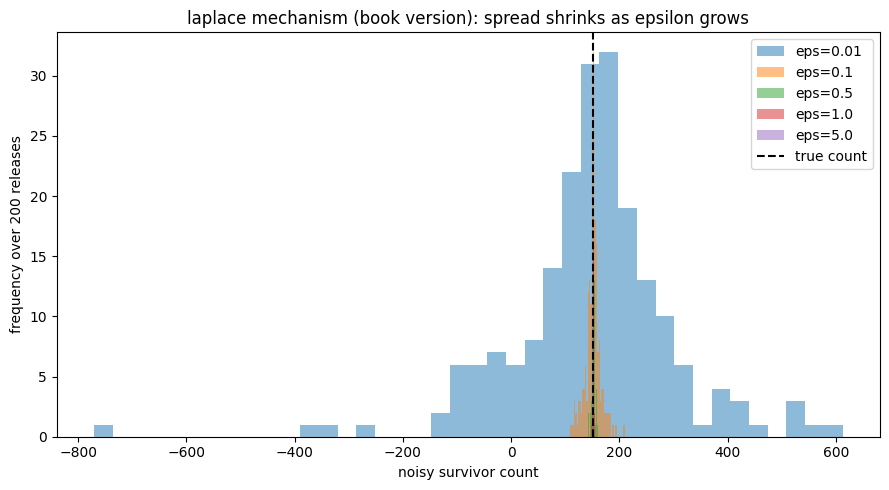

In [ ]:
plt.figure(figsize=(9, 5))
for eps in epsilons:
    plt.hist(count_runs[eps], bins=40, alpha=0.5, label="eps={}".format(eps))
plt.axvline(true_count, color="black", linestyle="--", label="true count")
plt.xlabel("noisy survivor count"); plt.ylabel("frequency over 200 releases")
plt.title("laplace mechanism (book version): spread shrinks as epsilon grows")
plt.legend(); plt.tight_layout(); plt.show()

## 3. exponential mechanism - on `Embarked`
book's listing in section 2.2.3. the utility of each candidate port is its count (divided by 1000, like the book's `/1000`); sensitivity is 1; the mechanism samples a port with probability proportional to `exp(eps * utility / (2 * sensitivity))`.

In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,270
C,102
Q,46


In [ ]:
embarked = df["Embarked"].dropna()
sets = embarked.unique()

In [ ]:
def most_common_embarked_exponential(x, A, H, sensitivity, epsilon):
    utilities = H(x, A)
    probabilities = [np.exp(epsilon * u / (2 * sensitivity)) for u in utilities]
    probabilities = probabilities / np.linalg.norm(probabilities, ord=1)
    return np.random.choice(A, 1, p=probabilities)[0]

print("true counts:", embarked.value_counts())
print("true most common port:", embarked.value_counts().idxmax())

true counts: Embarked
S    270
C    102
Q     46
Name: count, dtype: int64
true most common port: S


In [ ]:
def utility(data, sets):
    return data.value_counts()[sets] / 100

In [ ]:
# query across several epsilon values, 5000 draws each, to measure utility
true_mode = embarked.value_counts().idxmax()
print("epsilon | P(returns true mode) | distribution over 5000 draws")
for eps in [0.01, 0.1, 0.5, 1.0, 5.0]:
    draws = [most_common_embarked_exponential(embarked, sets, utility, 1, eps) for _ in range(5000)]
    vc = pd.Series(draws).value_counts()
    print("{:>6} | {:>20.3f} | {}".format(eps, vc.get(true_mode, 0) / 5000, dict(vc)))

epsilon | P(returns true mode) | distribution over 5000 draws
  0.01 |                0.335 | {'S': np.int64(1676), 'C': np.int64(1668), 'Q': np.int64(1656)}
   0.1 |                0.350 | {'S': np.int64(1751), 'C': np.int64(1633), 'Q': np.int64(1616)}
   0.5 |                0.442 | {'S': np.int64(2210), 'C': np.int64(1473), 'Q': np.int64(1317)}
   1.0 |                0.558 | {'S': np.int64(2792), 'C': np.int64(1269), 'Q': np.int64(939)}
   5.0 |                0.981 | {'S': np.int64(4905), 'C': np.int64(77), 'Q': np.int64(18)}


In [ ]:
def utility_unscaled(data, sets):
    return data.value_counts()[sets]

In [ ]:
print("epsilon | P(returns true mode) | distribution over 5000 draws")
for eps in [0.01, 0.1, 0.5, 1.0, 5.0]:
    draws = [most_common_embarked_exponential(embarked, sets, utility_unscaled, 1, eps) for _ in range(5000)]
    vc = pd.Series(draws).value_counts()
    print("{:>6} | {:>20.3f} | {}".format(eps, vc.get(true_mode, 0) / 5000, dict(vc)))

epsilon | P(returns true mode) | distribution over 5000 draws
  0.01 |                0.572 | {'S': np.int64(2862), 'C': np.int64(1198), 'Q': np.int64(940)}
   0.1 |                1.000 | {'S': np.int64(4999), 'C': np.int64(1)}
   0.5 |                1.000 | {'S': np.int64(5000)}
   1.0 |                1.000 | {'S': np.int64(5000)}
   5.0 |                1.000 | {'S': np.int64(5000)}


## insights - how the privacy budget impacts utility

**binary:** this mechanism tells the truth with probability set by `p`. at `p=0.5` (eps=ln(3)) a quarter of answers are flipped, so the reported survivor count is pulled toward `n/2`; as `p` rises toward 0.9 the budget grows and the count approaches the true value. the noise is unbiased in aggregate but each individual answer is deniable.

**laplace:** the released value is `f(data) + Lap(sensitivity/eps)`, so it is unbiased at every budget (the mean over many releases sits on the true value), but the standard deviation is `sensitivity/eps` and explodes as eps shrinks. the survivor count (sensitivity 1) is swamped at eps=0.01 but near-exact at eps=5.0; the bounded mean-fare query has tiny sensitivity, so it tolerates small budgets far better.

**exponential:** with the book's utility (counts `/100`) the utilities here are tiny ( app. 0.27, since the dataset is small), so `exp(eps*u/2)` is almost flat and the mode barely wins even at eps=5 - a quirk of reusing the book's census-scaled `/100` on a much smaller file. dropping the `/100` restores the intended behaviour: at tiny epsilon the selection is almost uniform over the three ports (strong privacy, useless answer), and as epsilon grows the probability mass concentrates on the true mode ('S') and the mechanism returns it almost every time.

**overall:** small epsilon buys privacy at the cost of utility (noisier counts, wider spreads, near-random selection); large epsilon recovers utility while weakening the guarantee - and sensitivity scales the effect, so low-sensitivity queries stay usable at much smaller budgets.